In [74]:
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

import datachain as dc 
from datachain.func.path import file_ext, file_stem, name, parent
from datachain.func.string import split
from transformers import Pipeline, pipeline
from datachain import File

from FantAIno.constants import (
    S3_GENERAL_PURPOSE_BUCKET_NAME,
    S3_ALBUM_DATA_TABLE_BUCKET_NAME,
    S3_EMBEDDINGS_TABLE_BUCKET_NAME,
    S3_EMBEDDINGS_DATABASE_NAME,
    S3_ALBUM_DATA_DATABASE_NAME,
    S3_SMALL_EMBEDDINGS_TABLE,
    S3_LARGE_EMBEDDINGS_TABLE,
    S3_ALBUM_DATA_TABLE
)
from FantAIno.utils.data_utils import get_secret
from FantAIno.utils.s3_utils import retrieve_s3_table_catalog

# Loading in a Multi-Modal Dataset from S3 with DataChain

In [49]:
image_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/album_art\*",
    type="image", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .limit(100)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [4]:
image_df.show(3)

,file,file,path
,path,size,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg
1,album_art\$uicideboy$___I Want to Die in New O...,38617,album_art\$uicideboy$___I Want to Die in New O...
2,album_art\$uicideboy$___Long Term Effects of S...,443669,album_art\$uicideboy$___Long Term Effects of S...



[Limited by 3 rows]


In [ ]:
lyrics_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/lyrics\*",
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .limit(100)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [6]:
lyrics_df.show(3)

,file,file,path
,path,size,
0,lyrics\$NOT___Ethereal.jsonl,32775,lyrics\$NOT___Ethereal.jsonl
1,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,lyrics\$uicideboy$___I Want to Die in New Orle...
2,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,lyrics\$uicideboy$___Long Term Effects of SUFF...



[Limited by 3 rows]


In [19]:
dc_catalog = (
    image_df
    .settings(cache=True)
    .merge(lyrics_df, on=name(file_stem((image_df.c("file.path")))))
    .persist()
)

In [21]:
dc_catalog.show(include_hidden=True)

,file,file,file,file,file,file,file,file,path,right_file,right_file,right_file,right_file,right_file,right_file,right_file,right_file,right_path
,source,path,size,version,etag,is_latest,last_modified,location,,source,path,size,version,etag,is_latest,last_modified,location,
0,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$NOT___Ethereal.jsonl,32775,5VMyF0k7SprY6E0MhcIwPtHEXNXf..Dn,ae2f5afc656b2754dfb3214ec539240a,True,2026-05-02 08:08:46+00:00,None,lyrics\$NOT___Ethereal.jsonl
1,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,oqYTUds011b5_rYuF8YENrmEodBS975F,0c01434f6c3cf2142cf27875ea4f460f,True,2026-05-02 17:35:54+00:00,None,lyrics\$uicideboy$___I Want to Die in New Orle...
2,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,7Md9AIbQ6z_neYXoive8wMX4U3W6j0fL,909033741937a5ccb4fe64f4456ec495,True,2026-05-02 09:32:12+00:00,None,lyrics\$uicideboy$___Long Term Effects of SUFF...
3,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\$uicideboy$___New World Depression.jsonl,39757,28Yc7TInfQjQP01hB9P5_UIQzXa6xEFy,c11c4b87e3ba7f944e4b8b3df43ce652,True,2026-05-02 01:06:22+00:00,None,lyrics\$uicideboy$___New World Depression.jsonl
4,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\070 Shake___You Cant Kill Me.jsonl,24121,p6lFidSafJCAc0yHXwPhyPH7BFn4zt4p,130b8f7d083cea7f4162965e8c403f9e,True,2026-05-02 07:16:23+00:00,None,lyrics\070 Shake___You Cant Kill Me.jsonl
5,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,"lyrics\100 gecs___10,000 gecs.jsonl",20770,l.Lw2sLLiS2VkekFR.KJE_BZmjXr.DdL,b368e7d821f9e8b4dbf6341be01c8438,True,2026-05-02 05:09:23+00:00,None,"lyrics\100 gecs___10,000 gecs.jsonl"
6,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\100 gecs___1000 gecs and The Tree of Cl...,40381,5cS8dIhXOmZE0OHlTSRgRQQdlTIp6fey,55d0a58d410e635b01ab4b876c8e2e26,True,2026-05-02 12:25:00+00:00,None,lyrics\100 gecs___1000 gecs and The Tree of Cl...
7,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Ethereal.jpg,27229,cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr,addc3053ccaf2f6826ad906b9f8bd5fe,True,2026-05-02 08:08:28+00:00,None,album_art\$NOT___Ethereal.jpg,s3://fantaino-bucket-085777795487-us-east-2-an,lyrics\100 gecs___1000 gecs.jsonl,16731,j_yxrTYwF4lHP0N29NI8ebLRQR.AaQ0C,73e95531b89a99d4b198aafea1bb6157,True,2026-05-02 15:33:48+00:00,None,lyrics\100 gecs___1000 gecs.jsonl
8,s3://fantaino-bucket-085777795487-us-east-2-an,album_art\$NOT___Et


[Limited by 20 rows]


In [24]:
dc_catalog.show()

,file,file,path,right_file,right_file,right_path
,path,size,,path,size,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$NOT___Ethereal.jsonl,32775,lyrics\$NOT___Ethereal.jsonl
1,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___I Want to Die in New Orle...,36797,lyrics\$uicideboy$___I Want to Die in New Orle...
2,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___Long Term Effects of SUFF...,31488,lyrics\$uicideboy$___Long Term Effects of SUFF...
3,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\$uicideboy$___New World Depression.jsonl,39757,lyrics\$uicideboy$___New World Depression.jsonl
4,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\070 Shake___You Cant Kill Me.jsonl,24121,lyrics\070 Shake___You Cant Kill Me.jsonl
5,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,"lyrics\100 gecs___10,000 gecs.jsonl",20770,"lyrics\100 gecs___10,000 gecs.jsonl"
6,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\100 gecs___1000 gecs and The Tree of Cl...,40381,lyrics\100 gecs___1000 gecs and The Tree of Cl...
7,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\100 gecs___1000 gecs.jsonl,16731,lyrics\100 gecs___1000 gecs.jsonl
8,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,lyrics\2 Chainz___Rap or Go to the League.jsonl,44643,lyrics\2 Chainz___Rap or Go to the League.jsonl



[Limited by 20 rows]


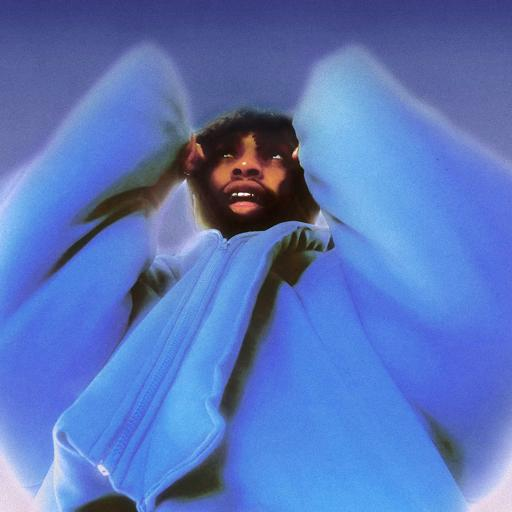

In [35]:
example = list(image_df)[0]
example[0].read()

In [36]:
example

(ImageFile(source='s3://fantaino-bucket-085777795487-us-east-2-an', path='album_art\\$NOT___Ethereal.jpg', size=27229, version='cWCWit8Zp.CCGEusjTKrqkdqaW_OGEKr', etag='addc3053ccaf2f6826ad906b9f8bd5fe', is_latest=True, last_modified=datetime.datetime(2026, 5, 2, 8, 8, 28, tzinfo=datetime.timezone.utc), location=None),
 'album_art\\$NOT___Ethereal.jpg')

In [ ]:
import matplotlib.pyplot as plt
from textwrap import wrap

count = chain.count()
_, axes = plt.subplots(1, count, figsize=(15, 5))

for ax, (img_file, caption) in zip(axes, chain.to_iter("file", "scene")):
    ax.imshow(img_file.read(), cmap="gray")
    ax.axis("off")
    wrapped_caption = "\n".join(wrap(caption.strip(), 40))
    ax.set_title(wrapped_caption, fontsize=10, pad=20)

plt.tight_layout()
plt.show()

# Loading from S3 Table Buckets

In [26]:
embeddings_catalog_name = S3_EMBEDDINGS_TABLE_BUCKET_NAME
account_id = get_secret("AWS_ACCOUNT_ID")
s3tablebucketname = S3_EMBEDDINGS_TABLE_BUCKET_NAME
region = get_secret("PYICEBERG_AWS_DEFAULT_REGION")

In [51]:
# Retrieve the S3 embeddings table catalog
embeddings_catalog = retrieve_s3_table_catalog(
    catalog_name=embeddings_catalog_name,
    account_id=account_id,
    s3tablebucketname=s3tablebucketname,
    region=region,
)

# Specify the database and table name for embeddings
small_embeddings_table = embeddings_catalog.load_table(f"{S3_EMBEDDINGS_DATABASE_NAME}.{S3_SMALL_EMBEDDINGS_TABLE}")

# Scan all records in the embeddings table and convert to Pandas DataFrame
all_records_arrow = small_embeddings_table.scan().to_arrow()
embeddings_pd = all_records_arrow.to_pandas()

print(embeddings_pd.head())

                    artist_name                 album_name  embedding_dim_0  \
0                  Little Women                     Throat         0.015394   
1                         Liars                Sisterworld         0.065212   
2             Portugal. The Man            American Ghetto         0.027352   
3                       Melvins  The Bride Screamed Murder         0.042054   
4  Ariel Pinks Haunted Graffiti               Before Today         0.042316   

   embedding_dim_1  embedding_dim_2  embedding_dim_3  embedding_dim_4  \
0        -0.034816        -0.009337         0.014463         0.007346   
1         0.002245         0.001368        -0.005359        -0.017730   
2        -0.017791        -0.001627        -0.011750         0.002927   
3        -0.009212         0.009545        -0.026684        -0.040211   
4        -0.023333        -0.011047        -0.013707        -0.012073   

   embedding_dim_5  embedding_dim_6  embedding_dim_7  ...  embedding_dim_1526  \
0    

# Creating Multi-Modal Datasets

Earlier, we used a limited size. Now we merge the whole shebang.

In [90]:
image_df = (dc.read_storage(
    rf"s3://{S3_GENERAL_PURPOSE_BUCKET_NAME}/album_art\*",
    type="image", 
    client_config = {
        "key": get_secret("AWS_ACCESS_KEY_ID"),
        "secret": get_secret("AWS_SECRET_ACCESS_KEY")
    }
)
    .settings(cache=True)
    .map(path=lambda file: file.path, output=str)
    .persist()
)

In [91]:
embeddings_df = dc.read_pandas(embeddings_pd)

In [92]:
embeddings_df.show(3)

,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,embedding_dim_226,


[Limited by 3 rows]


In [109]:
image_df_with_join_key = image_df.map(id=lambda file: file.path.split("\\")[-1].rsplit(".", 1)[0], params=["file"], output=str)
embeddings_df_with_join_key = embeddings_df.map(id=lambda artist_name, album_name: f"{artist_name}___{album_name}", params=["artist_name", "album_name"])

In [110]:
image_df_with_join_key.show(3)

,file,file,path,id
,path,size,,
0,album_art\$NOT___Ethereal.jpg,27229,album_art\$NOT___Ethereal.jpg,$NOT___Ethereal
1,album_art\$uicideboy$___I Want to Die in New O...,38617,album_art\$uicideboy$___I Want to Die in New O...,$uicideboy$___I Want to Die in New Orleans
2,album_art\$uicideboy$___Long Term Effects of S...,443669,album_art\$uicideboy$___Long Term Effects of S...,$uicideboy$___Long Term Effects of SUFFERING



[Limited by 3 rows]


In [94]:
embeddings_df_with_join_key.show(3)

Preparing: 0 rows [00:00, ? rows/s]

,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,embedding_dim_226,


[Limited by 3 rows]


In [114]:
multi_modal_df = (
    image_df_with_join_key
    .settings(cache=True)
    .merge(
        embeddings_df_with_join_key, 
        on=dc.C.id,
        inner=False,
        full=False
    )
    .persist()
)

Preparing: 0 rows [00:00, ? rows/s]

In [115]:
multi_modal_df.show(3)

,file,file,path,id,artist_name,album_name,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19,embedding_dim_20,embedding_dim_21,embedding_dim_22,embedding_dim_23,embedding_dim_24,embedding_dim_25,embedding_dim_26,embedding_dim_27,embedding_dim_28,embedding_dim_29,embedding_dim_30,embedding_dim_31,embedding_dim_32,embedding_dim_33,embedding_dim_34,embedding_dim_35,embedding_dim_36,embedding_dim_37,embedding_dim_38,embedding_dim_39,embedding_dim_40,embedding_dim_41,embedding_dim_42,embedding_dim_43,embedding_dim_44,embedding_dim_45,embedding_dim_46,embedding_dim_47,embedding_dim_48,embedding_dim_49,embedding_dim_50,embedding_dim_51,embedding_dim_52,embedding_dim_53,embedding_dim_54,embedding_dim_55,embedding_dim_56,embedding_dim_57,embedding_dim_58,embedding_dim_59,embedding_dim_60,embedding_dim_61,embedding_dim_62,embedding_dim_63,embedding_dim_64,embedding_dim_65,embedding_dim_66,embedding_dim_67,embedding_dim_68,embedding_dim_69,embedding_dim_70,embedding_dim_71,embedding_dim_72,embedding_dim_73,embedding_dim_74,embedding_dim_75,embedding_dim_76,embedding_dim_77,embedding_dim_78,embedding_dim_79,embedding_dim_80,embedding_dim_81,embedding_dim_82,embedding_dim_83,embedding_dim_84,embedding_dim_85,embedding_dim_86,embedding_dim_87,embedding_dim_88,embedding_dim_89,embedding_dim_90,embedding_dim_91,embedding_dim_92,embedding_dim_93,embedding_dim_94,embedding_dim_95,embedding_dim_96,embedding_dim_97,embedding_dim_98,embedding_dim_99,embedding_dim_100,embedding_dim_101,embedding_dim_102,embedding_dim_103,embedding_dim_104,embedding_dim_105,embedding_dim_106,embedding_dim_107,embedding_dim_108,embedding_dim_109,embedding_dim_110,embedding_dim_111,embedding_dim_112,embedding_dim_113,embedding_dim_114,embedding_dim_115,embedding_dim_116,embedding_dim_117,embedding_dim_118,embedding_dim_119,embedding_dim_120,embedding_dim_121,embedding_dim_122,embedding_dim_123,embedding_dim_124,embedding_dim_125,embedding_dim_126,embedding_dim_127,embedding_dim_128,embedding_dim_129,embedding_dim_130,embedding_dim_131,embedding_dim_132,embedding_dim_133,embedding_dim_134,embedding_dim_135,embedding_dim_136,embedding_dim_137,embedding_dim_138,embedding_dim_139,embedding_dim_140,embedding_dim_141,embedding_dim_142,embedding_dim_143,embedding_dim_144,embedding_dim_145,embedding_dim_146,embedding_dim_147,embedding_dim_148,embedding_dim_149,embedding_dim_150,embedding_dim_151,embedding_dim_152,embedding_dim_153,embedding_dim_154,embedding_dim_155,embedding_dim_156,embedding_dim_157,embedding_dim_158,embedding_dim_159,embedding_dim_160,embedding_dim_161,embedding_dim_162,embedding_dim_163,embedding_dim_164,embedding_dim_165,embedding_dim_166,embedding_dim_167,embedding_dim_168,embedding_dim_169,embedding_dim_170,embedding_dim_171,embedding_dim_172,embedding_dim_173,embedding_dim_174,embedding_dim_175,embedding_dim_176,embedding_dim_177,embedding_dim_178,embedding_dim_179,embedding_dim_180,embedding_dim_181,embedding_dim_182,embedding_dim_183,embedding_dim_184,embedding_dim_185,embedding_dim_186,embedding_dim_187,embedding_dim_188,embedding_dim_189,embedding_dim_190,embedding_dim_191,embedding_dim_192,embedding_dim_193,embedding_dim_194,embedding_dim_195,embedding_dim_196,embedding_dim_197,embedding_dim_198,embedding_dim_199,embedding_dim_200,embedding_dim_201,embedding_dim_202,embedding_dim_203,embedding_dim_204,embedding_dim_205,embedding_dim_206,embedding_dim_207,embedding_dim_208,embedding_dim_209,embedding_dim_210,embedding_dim_211,embedding_dim_212,embedding_dim_213,embedding_dim_214,embedding_dim_215,embedding_dim_216,embedding_dim_217,embedding_dim_218,embedding_dim_219,embedding_dim_220,embedding_dim_221,embedding_dim_222,embedding_dim_223,embedding_dim_224,embedding_dim_225,


[Limited by 3 rows]


In [116]:
multi_modal_df.count()

3421

# To Do: 

1) Filter to show where missing data is located (when you run on inner like 450 rows disappear).
2) Include album data.
3) Drop unnecessary columns.
4) Speed up?